In [3]:
import pandas as pd
import numpy as np
import shap
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import  f_regression
from sklearn.metrics import make_scorer, precision_score, recall_score, roc_auc_score, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
import joblib

In [4]:
data = pd.read_csv("softball_data.csv")
data.isna().sum()

Player      0
POS         0
BA_Home     0
OBP_Home    0
SLG_Home    0
OPS_Home    0
GP_Home     0
PA_Home     0
AB_Home     0
R_Home      0
H_Home      0
2B_Home     0
3B_Home     0
HR_Home     0
RBI_Home    0
HBP_Home    0
BB_Home     0
K_Home      0
SB_Home     0
CS_Home     0
BA_Away     0
OBP_Away    0
SLG_Away    0
OPS_Away    0
GP_Away     0
PA_Away     0
AB_Away     0
R_Away      2
H_Away      0
2B_Away     0
3B_Away     0
HR_Away     0
RBI_Away    0
HBP_Away    0
BB_Away     0
K_Away      0
SB_Away     0
CS_Away     0
PS          0
WS          0
P4          0
dtype: int64

In [4]:
data.head()

,Player,POS,BA_Home,OBP_Home,SLG_Home,OPS_Home,GP_Home,PA_Home,AB_Home,R_Home,...,HR_Away,RBI_Away,HBP_Away,BB_Away,K_Away,SB_Away,CS_Away,PS,WS,P4
0,Morgan Petty,RF,0.545,0.643,0.939,1.582,12,42,33,10,...,2,8,8,4,9,8,3,0.185,0,0
1,Ella Squaires,LF,0.475,0.575,0.525,1.101,19,73,59,21,...,0,4,0,3,6,4,2,0.169,0,0
2,Ashley Della Guardia,1B,0.444,0.516,0.833,1.349,19,64,54,16,...,0,3,0,9,6,1,0,0.256,0,0
3,Emily Riggs,2B,0.418,0.492,0.782,1.274,19,63,55,10,...,1,5,1,9,19,0,0,0.236,0,0
4,Caitlyn Mitros,LF,0.417,0.475,0.528,1.003,11,40,36,7,...,0,3,0,4,3,4,2,0.143,0,0


In [5]:
X = data.drop('P4', axis = 1)
y = data['P4']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 307)

In [15]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns.tolist()

num_pipe = Pipeline([
    ('impute', SimpleImputer()),  
    ('poly', PolynomialFeatures(include_bias=False)),  
    ('standardize', StandardScaler())
])

cat_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

In [7]:
params = {
    'preprocessor__num__impute__strategy': ['mean', 'median'],  
    'preprocessor__num__poly__degree': [1, 2, 3],  
    'classifier__C': np.logspace(-4, 4, 20),  
    'classifier__penalty': ['l1', 'l2', 'elasticnet'], 
    'classifier__l1_ratio': np.linspace(0, 1, 10)  
}

In [16]:
smote = SMOTE(sampling_strategy='auto', random_state=42)

In [9]:
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', LogisticRegression(max_iter=500, solver='saga'))
])

In [ ]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': 'roc_auc'
}

# Perform Randomized Search with multiple metrics
random_search = RandomizedSearchCV(
    log_reg, param_distributions=params, 
    n_iter=100, cv=5, scoring=scoring_metrics, 
    refit='f1', random_state=42
)

random_search.fit(X_train, y_train)


In [11]:

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])  

print("Best Parameters:", random_search.best_params_)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")

Best Parameters: {'preprocessor__num__poly__degree': 2, 'preprocessor__num__impute__strategy': 'mean', 'classifier__penalty': 'l1', 'classifier__l1_ratio': 0.5555555555555556, 'classifier__C': 0.004832930238571752}
Accuracy:  0.7707
F1 Score:  0.3814
Precision: 0.3534
Recall:    0.4141
AUC-ROC:   0.7081


In [35]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy='mean')),  
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),  
        ("scale", StandardScaler())  
    ]), X_train.select_dtypes(include=['int64', 'float64']).columns)  # Adjust column selection if needed
])

# Rebuild the logistic regression model with best parameters
logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", LogisticRegression(
        C=0.004832930238571752,
        penalty='l1',
        l1_ratio=0.55555556, 
        max_iter=500,
        solver="saga"
    ))
])

# Train the model
logreg_model.fit(X_train, y_train)

import joblib
joblib.dump(logreg_model, "logreg_model.pkl")

c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


['logreg_model.pkl']

In [36]:
y_pred1 = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)
roc_auc = roc_auc_score(y_test, logreg_model.predict_proba(X_test)[:, 1])  


print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")

Accuracy:  0.7690
F1 Score:  0.3796
AUC-ROC:   0.7079


In [9]:
params2 = {
    'preprocessor__num__impute__strategy': ['mean', 'median'],  
    'preprocessor__num__poly__degree': [1, 2, 3],  
    'classifier__n_estimators': [50, 100, 200, 500],  # Number of trees
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],  # Shrinkage step size
    'classifier__max_depth': [3, 5, 7, 10],  # Depth of trees
    'classifier__alpha': np.logspace(-1, .5, 2) #L1 (lasso)
}

In [10]:
boost = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier',LGBMClassifier())
])

In [ ]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': 'roc_auc'
}

# Perform Randomized Search with multiple metrics
random_search = RandomizedSearchCV(
    boost, param_distributions=params2, 
    n_iter=100, cv=5, scoring=scoring_metrics, 
    refit='f1', random_state=42
)

random_search.fit(X_train, y_train)

In [12]:

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])  

print("Best Parameters:", random_search.best_params_)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")

Best Parameters: {'preprocessor__num__poly__degree': 1, 'preprocessor__num__impute__strategy': 'mean', 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__alpha': 3.1622776601683795}
Accuracy:  0.7879
F1 Score:  0.3941
Precision: 0.3846
Recall:    0.4040
AUC-ROC:   0.7272


c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy='mean')),  
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),  
        ("scale", StandardScaler())  
    ]), X_train.select_dtypes(include=['int64', 'float64']).columns)  # Adjust column selection if needed
])

# Rebuild the logistic regression model with best parameters
boostmodel = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("classifier", LGBMClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.01,
        alpha =  3.1622776601683795
    ))
])

# Train the model
boostmodel.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1434, number of negative: 1434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9253
[LightGBM] [Info] Number of data points in the train set: 2868, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=1,
                                                                                      include_bias=False)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['BA_Home', 'OBP_Home', 'SLG_Home', 'OPS_Home', 'GP_Home', 'PA_Home',
       'AB_Home', 'R_Home', 'H_Home', '2B_Home', '3B_Home', 'HR_Home',
       'RBI_Home', 'HBP_Home',...
       'BA_Away', 'OBP_Away', 'SLG_Away', 'OPS_Away', 'GP_Away', 'PA_Away',
       'AB_Away', 'R_Away', 'H_Away', '2B_Away', '3B_Away', 'HR_Away',
       'RBI_Away', 'HBP_Away', 'BB_Away', 'K_Away', 'SB_Away', 'CS_Away', 'PS',
       'WS'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LGBMClassifier(alpha=3.1622776601683795, learning_rate=0.01,
                                max_depth=3, n_estimators=200))])

In [19]:

y_pred = boostmodel.predict(X_test)

c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
joblib.dump(random_search, 'boost.pkl')

['boost.pkl']

In [5]:
logreg_model = joblib.load('logreg_model.pkl')

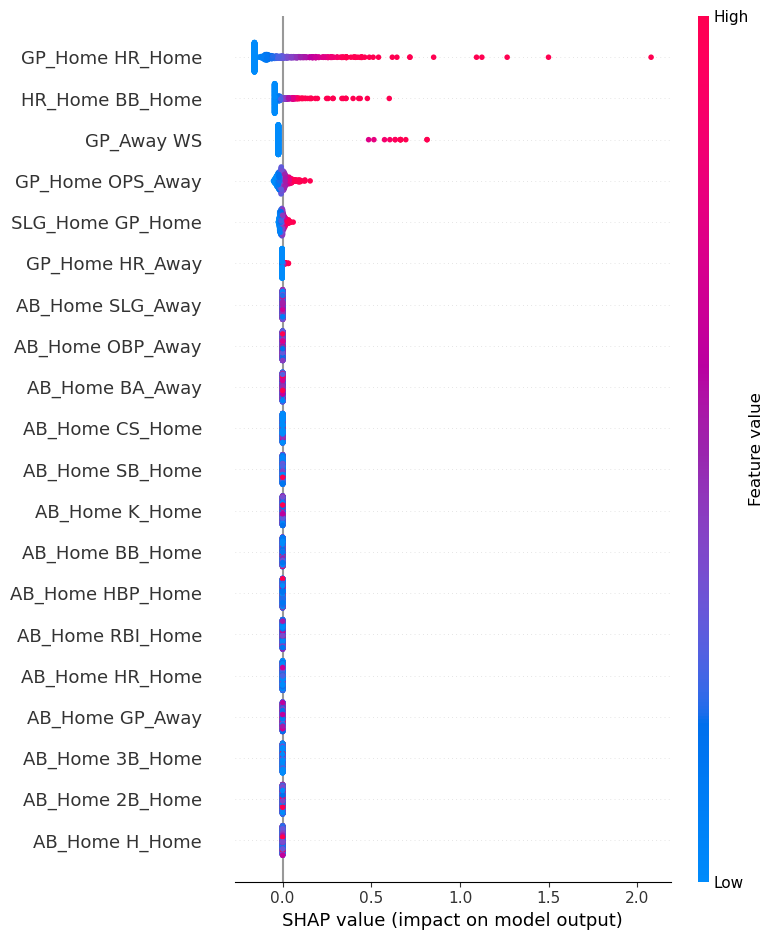

<Figure size 640x480 with 0 Axes>

In [51]:
import matplotlib.pyplot as plt

# Extract preprocessing and classifier separately
preprocessor = logreg_model.named_steps["preprocessor"]
classifier = logreg_model.named_steps["classifier"]

# Transform data using the preprocessor
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Use SHAP's LinearExplainer (best for logistic regression)
explainer = shap.LinearExplainer(classifier, X_train_transformed)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

# Extract numerical feature names before transformation
num_feature_names = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Extract transformed feature names after PolynomialFeatures
poly = preprocessor.named_transformers_["num"].named_steps["poly"]
poly_feature_names = poly.get_feature_names_out(input_features=num_feature_names)

# Ensure the number of features matches
if X_train_transformed.shape[1] != len(poly_feature_names):
    print(f"Warning: Shape mismatch - Transformed data has {X_train_transformed.shape[1]} features, but extracted {len(poly_feature_names)} names.")
    poly_feature_names = [f"Feature {i}" for i in range(X_train_transformed.shape[1])]  # Fallback to generic names

# SHAP Summary Plot with Correct Feature Names
shap.summary_plot(shap_values, X_test_transformed, feature_names=poly_feature_names)

plt.savefig("logregfeatures.png", dpi=72, bbox_inches="tight")
plt.show()


In [6]:
boost_model = joblib.load('boost.pkl')

c:\Users\fellars\miniconda3\envs\my_env\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


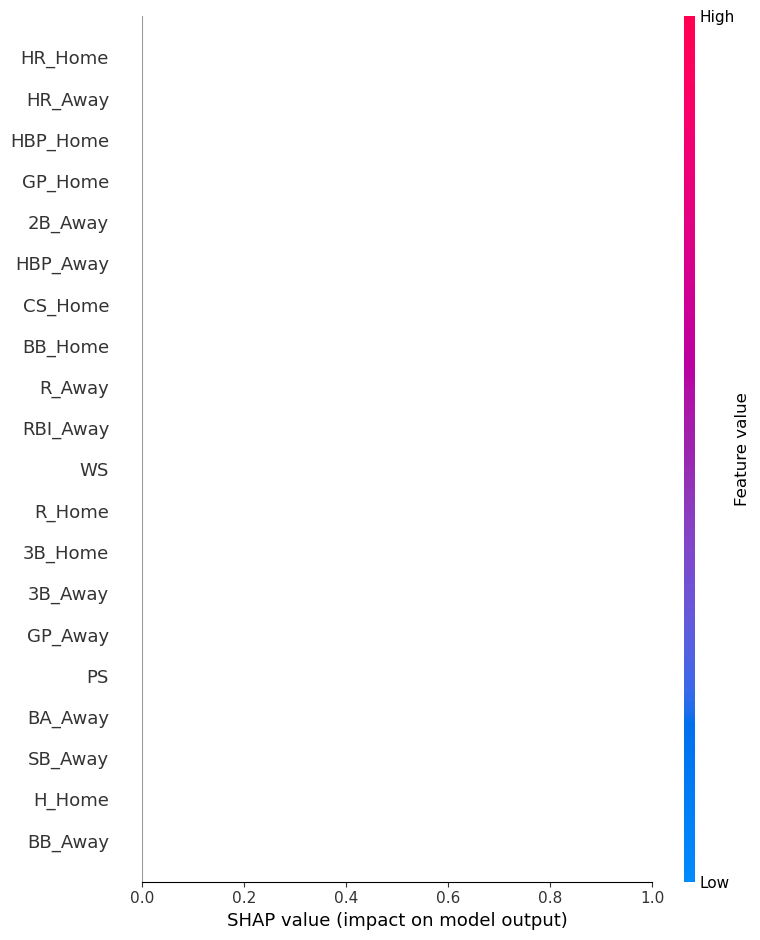

<Figure size 640x480 with 0 Axes>

In [33]:
import matplotlib.pyplot as plt

preprocessor = boostmodel.named_steps["preprocessor"]
classifier = boostmodel.named_steps["classifier"]

# Transform data using the preprocessor
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# SHAP Explainer for Tree-based models
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

# Extract numerical feature names before transformation
num_feature_names = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Extract transformed feature names from PolynomialFeatures
poly = preprocessor.named_transformers_["num"].named_steps["poly"]

# Get numerical feature names (this assumes you have the original column names in a list)
poly_feature_names = poly.get_feature_names_out(input_features=num_feature_names)

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=poly_feature_names)

shap.summary_plot(shap_values, X_test_transformed_df, plot_type="beeswarm")



plt.savefig("boostedshap.png", dpi=72, bbox_inches="tight")
plt.show()


(580, 38)
(580, 38)


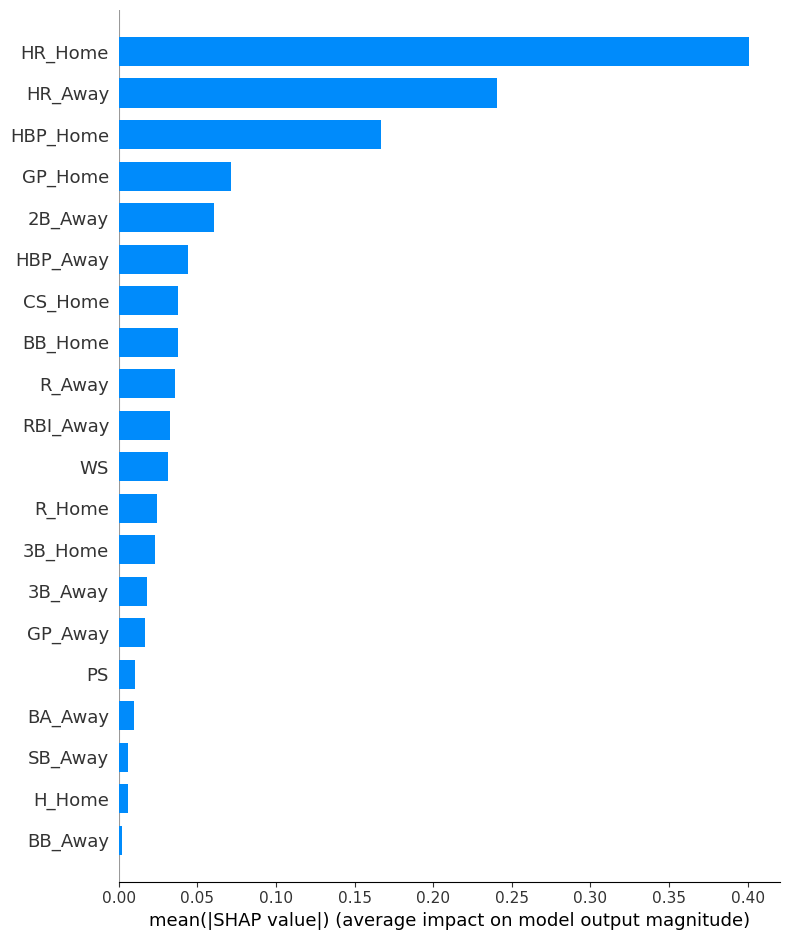

<Figure size 640x480 with 0 Axes>

In [45]:
X_test_df = pd.DataFrame(X_test_transformed, columns=poly_feature_names)
print(X_test_df.shape)
print(shap_values.shape)

shap.summary_plot(shap_values, X_test_df, plot_type="bar")

plt.savefig("boostedshap.png", dpi=72, bbox_inches="tight")
plt.show()


In [13]:
importance = boost_model.named_steps["classifier"].booster_.feature_importance()

# Get feature names (adjust if you used any preprocessing)
num_feature_names = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Access the PolynomialFeatures transformer in your pipeline
poly = best_model.named_steps["preprocessor"].named_transformers_["num"].named_steps["poly"]
poly_feature_names = poly.get_feature_names_out(input_features=num_feature_names)

# If you used one-hot encoding for categorical features in your pipeline, access those feature names
categorical_feature_names = best_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out()

# Combine numerical and categorical feature names
feature_names = poly_feature_names.tolist() + categorical_feature_names.tolist()

# Combine feature names and importances for sorting
feature_importance = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)

# Get the top 10 features
top_features = feature_importance[:20]
top_feature_names = [f[0] for f in top_features]
top_feature_importances = [f[1] for f in top_features]

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_feature_names, top_feature_importances)
plt.xlabel("Feature Importance")
plt.title("Top 20 LightGBM Feature Importance")
plt.gca().invert_yaxis()  # Invert the y-axis to have the top features at the top

plt.savefig("boostedfeatures.png", dpi=72, bbox_inches="tight")
plt.show()

AttributeError: 'RandomizedSearchCV' object has no attribute 'named_steps'